In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("realtor-data.csv")

print(df.head())
print("\n")

print(df.info())

   brokered_by    status     price  bed  bath  acre_lot     street  \
0     103378.0  for_sale  105000.0  3.0   2.0      0.12  1962661.0   
1      52707.0  for_sale   80000.0  4.0   2.0      0.08  1902874.0   
2     103379.0  for_sale   67000.0  2.0   1.0      0.15  1404990.0   
3      31239.0  for_sale  145000.0  4.0   2.0      0.10  1947675.0   
4      34632.0  for_sale   65000.0  6.0   2.0      0.05   331151.0   

         city        state  zip_code  house_size prev_sold_date  
0    Adjuntas  Puerto Rico     601.0       920.0            NaN  
1    Adjuntas  Puerto Rico     601.0      1527.0            NaN  
2  Juana Diaz  Puerto Rico     795.0       748.0            NaN  
3       Ponce  Puerto Rico     731.0      1800.0            NaN  
4    Mayaguez  Puerto Rico     680.0         NaN            NaN  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   broke

In [3]:
float_columns = df.select_dtypes(include=['float'])
# Fill null values for each float column
for col in float_columns:
    df[col].fillna(df[col].mean(), inplace=True)

float_columns = df.select_dtypes(include=['object'])
# Fill null values for each float column
for col in float_columns:
    df[col].fillna(0, inplace=True)

null_counts = df.isnull().sum()
print("Null values in each column:")
print(null_counts)
print("\n")
print(df.head())


C:\Users\ellie\AppData\Local\Temp\ipykernel_15300\3313903492.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\ellie\AppData\Local\Temp\ipykernel_15300\3313903492.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

Null values in each column:
brokered_by       0
status            0
price             0
bed               0
bath              0
acre_lot          0
street            0
city              0
state             0
zip_code          0
house_size        0
prev_sold_date    0
dtype: int64


   brokered_by    status     price  bed  bath  acre_lot     street  \
0     103378.0  for_sale  105000.0  3.0   2.0      0.12  1962661.0   
1      52707.0  for_sale   80000.0  4.0   2.0      0.08  1902874.0   
2     103379.0  for_sale   67000.0  2.0   1.0      0.15  1404990.0   
3      31239.0  for_sale  145000.0  4.0   2.0      0.10  1947675.0   
4      34632.0  for_sale   65000.0  6.0   2.0      0.05   331151.0   

         city        state  zip_code   house_size prev_sold_date  
0    Adjuntas  Puerto Rico     601.0   920.000000              0  
1    Adjuntas  Puerto Rico     601.0  1527.000000              0  
2  Juana Diaz  Puerto Rico     795.0   748.000000              0  
3       Ponce  Puerto Rico  

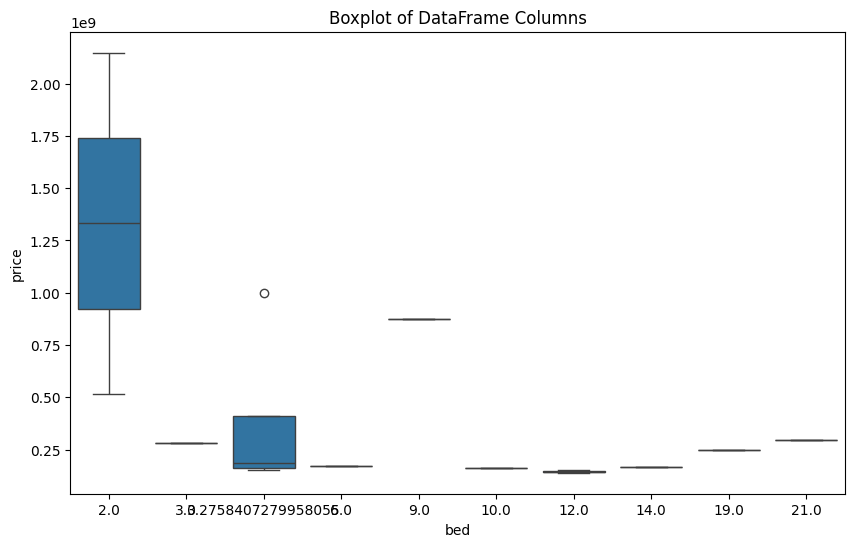

In [4]:
top_15 = df.nlargest(15, 'price')
plt.figure(figsize=(10, 6))
sns.boxplot(x='bed',y='price',data=top_15)
plt.title('Boxplot of DataFrame Columns')
plt.xticks(rotation=0)
plt.show()


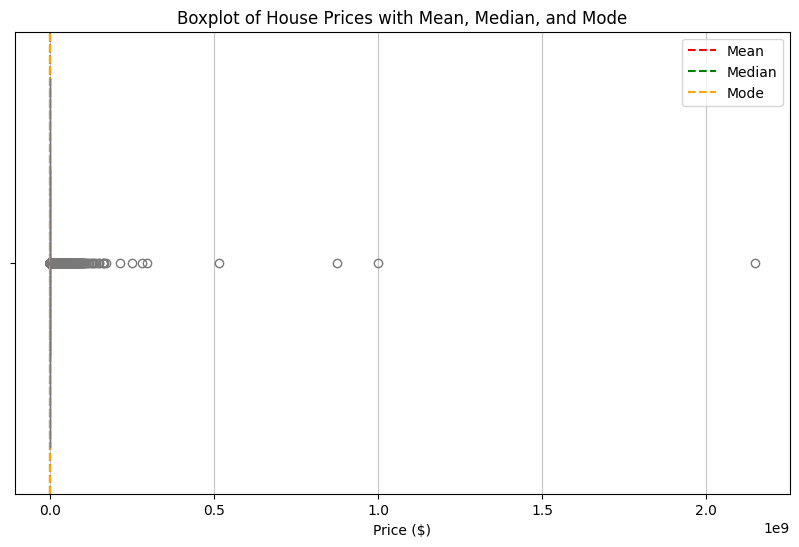

In [5]:
mean = df['price'].mean()

# Calculate the median
median = df['price'].median()

# Calculate the mode
mode = df['price'].mode()[0]

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'], color='lightblue')

# Add lines for mean, median, and mode
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.axvline(median, color='green', linestyle='--', label='Median')
plt.axvline(mode, color='orange', linestyle='--', label='Mode')

plt.title('Boxplot of House Prices with Mean, Median, and Mode')
plt.xlabel('Price ($)')
plt.legend()
plt.grid(axis='x', alpha=0.75)
plt.show()